In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../")
sys.path.append("../../../")
sys.path.append("../../../../")

from science_jubilee.machine_session import MachineSession
import detection
from science_jubilee.Vision.Duckweed_tracker.ingredients.segmentation import get_img_contour


def show(img, title=""):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

hardware=False

c:\Users\Justin\.conda\envs\marigold_env\lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


C:\Users\Justin\AppData\Local\Temp\ipykernel_53580\2664540472.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img =  imageio.imread("latest.png")


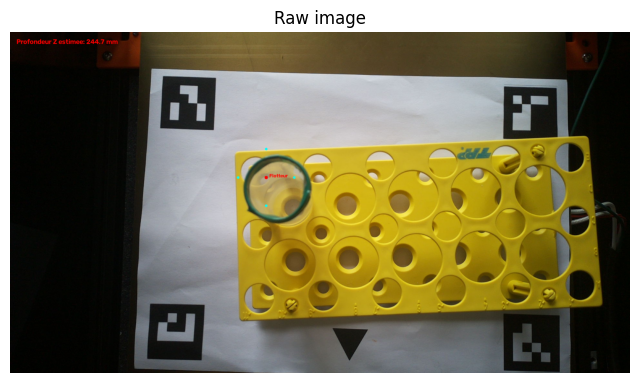

In [7]:


import imageio


if hardware:
    env = ".env.hardware"

    session = MachineSession.from_env(env)
    cam = session.camera
        
        # move camera to imaging position and capture
    X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
    cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

    img = cam.get_image()
    show(img, "Raw image")
else:
    env = ".env.mock"
    session = MachineSession.from_env(env)
    cam = session.camera
    X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
    img =  imageio.imread("latest.png")

show(img, "Raw image")
    

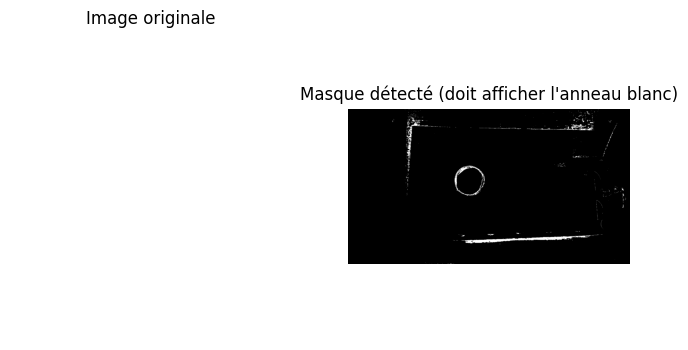

In [ ]:
import cv2
import matplotlib.pyplot as plt

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Plage verte très saturée (du vert vif au cyan/bleu-vert)
lower = np.array([30, 80, 30], dtype=np.uint8)
upper = np.array([105, 120, 100], dtype=np.uint8)

mask = cv2.inRange(hsv, lower, upper)
plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Masque détecté (doit afficher l'anneau blanc)")
plt.axis("off")
plt.show()

In [4]:
float_det=detection.main(
    img,
    cam,
    13.5)